# Practice 1: Data Processing Workflow — Retail Store Dataset

## Exploratory Data Analysis, Cleaning, Scaling & Visualization

This notebook applies a complete data processing pipeline — EDA, missing-value handling, outlier detection, feature scaling, and charting — on a real retail transaction dataset following the methodology in *Chương 2 — Quy trình trực quan hóa dữ liệu*.

| Step | Description | What it does | Import path |
|------|-------------|--------------|-------------|
| 1 | Import Libraries | Load pandas, numpy, matplotlib, seaborn, sklearn | — |
| 2 | Load Dataset | Read retail store Excel file + initial cleaning | — |
| 3 | Exploratory Data Analysis | Shape, info, describe, distributions, correlations | — |
| 4 | Handle Missing Values | Detect and impute missing data | — |
| 5 | Detect & Treat Outliers | IQR method, boxplots, outlier capping | — |
| 6 | Feature Scaling | Min-Max scaling and Standardization | — |
| 7 | Data Visualization | Bar, line, pie, scatter, heatmap, area, histogram charts | — |

---

In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

PLOT_DIR = Path('result/plots')
METRIC_DIR = Path('result/metrics')
PLOT_DIR.mkdir(parents=True, exist_ok=True)
METRIC_DIR.mkdir(parents=True, exist_ok=True)

PALETTE = {
    'Áo nam': '#3498db',
    'Áo nữ': '#e74c3c',
    'Áo trẻ em': '#2ecc71',
}

# Helper to format VND values as 'X.X triệu'
def fmt_trieu(x):
    return f'{x / 1e6:.1f} triệu'

print('All libraries loaded successfully.')

All libraries loaded successfully.


## 2. Load Dataset

The raw Excel file has two completely empty header rows at the top. The actual column names are in row index 2 (0-based). We skip the first two rows and use row 2 as the header.

In [2]:
# 2. Load Dataset with correct header row
df = pd.read_excel('../data/Du lieu cua hang.xlsx', header=2)

# Convert Ngay_GD to datetime
df['Ngay_GD'] = pd.to_datetime(df['Ngay_GD'])

# Extract temporal features
df['Thang'] = df['Ngay_GD'].dt.month
df['Thu'] = df['Ngay_GD'].dt.dayofweek
df['Ngay'] = df['Ngay_GD'].dt.day
df['Quy'] = df['Ngay_GD'].dt.quarter

print(f'Kích thước dữ liệu: {df.shape}')
print(f'Phạm vi ngày: {df["Ngay_GD"].min().date()} → {df["Ngay_GD"].max().date()}')
print(f'Tổng giao dịch: {len(df):,}')
print(f'Tổng khách hàng: {df["Ma_KH"].nunique():,}')
print(f'Tổng đơn hàng: {df["Ma_Don_hang"].nunique():,}')
print(f'Tổng doanh thu: {fmt_trieu(df["Doanh thu"].sum())} VND')

Kích thước dữ liệu: (1002, 13)
Phạm vi ngày: 2025-01-01 → 2025-12-31
Tổng giao dịch: 1,002
Tổng khách hàng: 149
Tổng đơn hàng: 429
Tổng doanh thu: 1401.0 triệu VND


In [3]:
# Display first 5 rows
df.head()

,STT,Ngay_GD,Ma_KH,Ma_Don_hang,Ma_SP,Ten_SP,So_luong,Gia_Don_Hang,Doanh thu,Thang,Thu,Ngay,Quy
0,1,2025-01-01,KH142,DH359,SP003,Áo nữ,2,380000,760000,1,2,1,1
1,2,2025-01-01,KH074,DH376,SP001,Áo nam,3,450000,1350000,1,2,1,1
2,3,2025-01-01,KH043,DH266,SP002,Áo nữ,4,380000,1520000,1,2,1,1
3,4,2025-01-02,KH121,DH421,SP001,Áo nữ,6,380000,2280000,1,3,2,1
4,5,2025-01-02,KH041,DH178,SP003,Áo nữ,7,380000,2660000,1,3,2,1


## 3. Exploratory Data Analysis (EDA)

Following the guide (Slide 6), we examine data types, quality, and relationships before visualization.

In [4]:
# 3a. Data structure and types
print('=== Thông tin dữ liệu ===')
print(df.info())
print()
print('=== Thống kê cơ bản ===')
df.describe()

=== Thông tin dữ liệu ===
<class 'pandas.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   STT           1002 non-null   int64         
 1   Ngay_GD       1002 non-null   datetime64[us]
 2   Ma_KH         1002 non-null   str           
 3   Ma_Don_hang   1002 non-null   str           
 4   Ma_SP         1002 non-null   str           
 5   Ten_SP        1002 non-null   str           
 6   So_luong      1002 non-null   int64         
 7   Gia_Don_Hang  1002 non-null   int64         
 8   Doanh thu     1002 non-null   int64         
 9   Thang         1002 non-null   int32         
 10  Thu           1002 non-null   int32         
 11  Ngay          1002 non-null   int32         
 12  Quy           1002 non-null   int32         
dtypes: datetime64[us](1), int32(4), int64(4), str(4)
memory usage: 86.2 KB
None

=== Thống kê cơ bản ===


,STT,Ngay_GD,So_luong,Gia_Don_Hang,Doanh thu,Thang,Thu,Ngay,Quy
count,1002.000000,1002,1002.000000,1002.000000,1.002000e+03,1002.000000,1002.000000,1002.00000,1002.000000
mean,501.500000,2025-06-28 17:16:10.059880,4.064870,343293.413174,1.398224e+06,6.422156,3.092814,15.61477,2.486028
min,1.000000,2025-01-01 00:00:00,1.000000,200000.000000,2.000000e+05,1.000000,0.000000,1.00000,1.000000
25%,251.250000,2025-03-29 00:00:00,2.000000,200000.000000,7.600000e+05,3.000000,1.000000,8.00000,1.000000
50%,501.500000,2025-06-27 00:00:00,4.000000,380000.000000,1.200000e+06,6.000000,3.000000,16.00000,2.000000
75%,751.750000,2025-10-02 00:00:00,6.000000,450000.000000,2.250000e+06,10.000000,5.000000,23.75000,4.000000
max,1002.000000,2025-12-31 00:00:00,7.000000,450000.000000,3.150000e+06,12.000000,6.000000,31.00000,4.000000
std,289.396786,NaN,2.009166,104040.892102,8.439860e+05,3.449135,1.998593,8.83941,1.130940


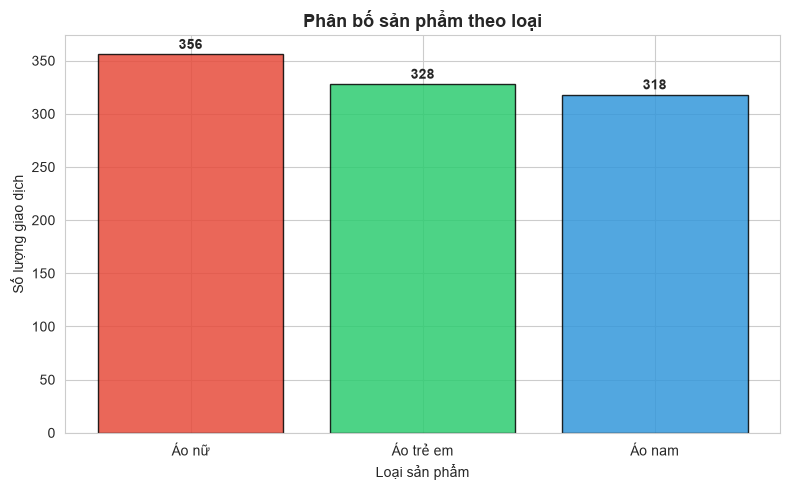

In [5]:
# 3b. Phân bố sản phẩm (Ten_SP)
fig, ax = plt.subplots(figsize=(8, 5))

counts = df['Ten_SP'].value_counts()
bar_colors = [PALETTE.get(v, '#95a5a6') for v in counts.index]
bars = ax.bar(counts.index, counts.values, color=bar_colors, edgecolor='black', alpha=0.85)
ax.set_title('Phân bố sản phẩm theo loại', fontsize=13, fontweight='bold')
ax.set_xlabel('Loại sản phẩm')
ax.set_ylabel('Số lượng giao dịch')
for i, v in enumerate(counts.values):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(PLOT_DIR / '3b_phan_bo_san_pham.png', dpi=100, bbox_inches='tight')
plt.show()

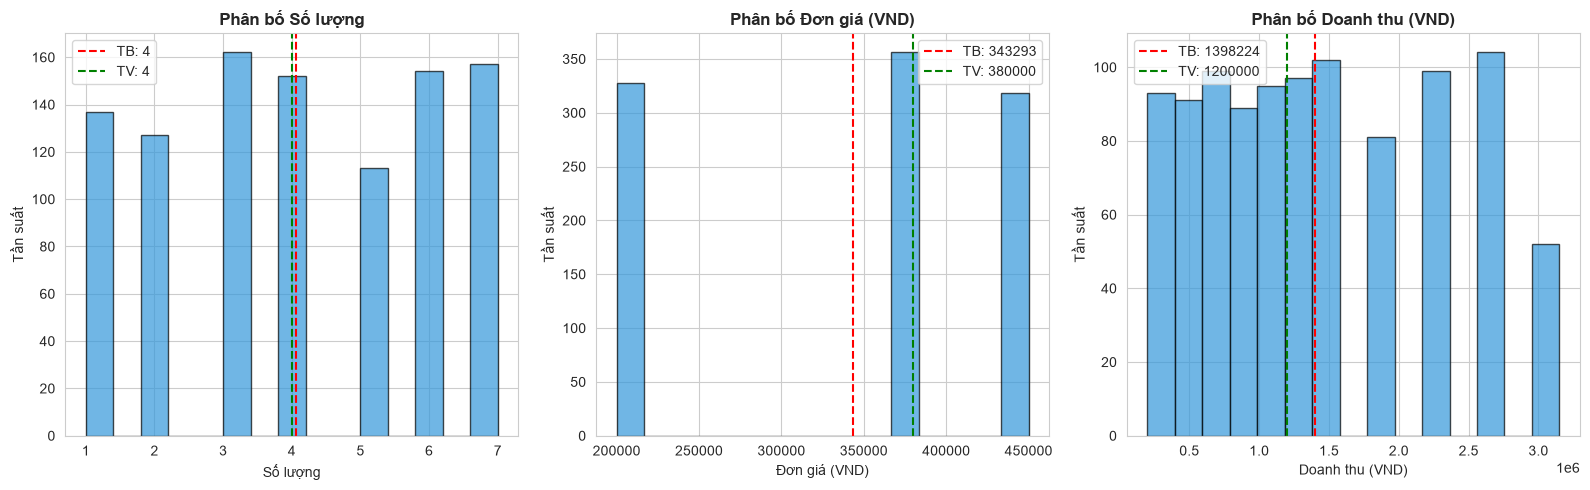

In [6]:
# 3c. Phân bố các biến số
num_cols = ['So_luong', 'Gia_Don_Hang', 'Doanh thu']
num_labels = {'So_luong': 'Số lượng', 'Gia_Don_Hang': 'Đơn giá (VND)', 'Doanh thu': 'Doanh thu (VND)'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, num_cols):
    ax.hist(df[col], bins=15, edgecolor='black', color='#3498db', alpha=0.7)
    ax.set_title(f'Phân bố {num_labels[col]}', fontsize=12, fontweight='bold')
    ax.set_xlabel(num_labels[col])
    ax.set_ylabel('Tần suất')
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'TB: {df[col].mean():.0f}')
    ax.axvline(df[col].median(), color='green', linestyle='--', label=f'TV: {df[col].median():.0f}')
    ax.legend()

plt.tight_layout()
plt.savefig(PLOT_DIR / '3c_phan_bo_bien_so.png', dpi=100, bbox_inches='tight')
plt.show()

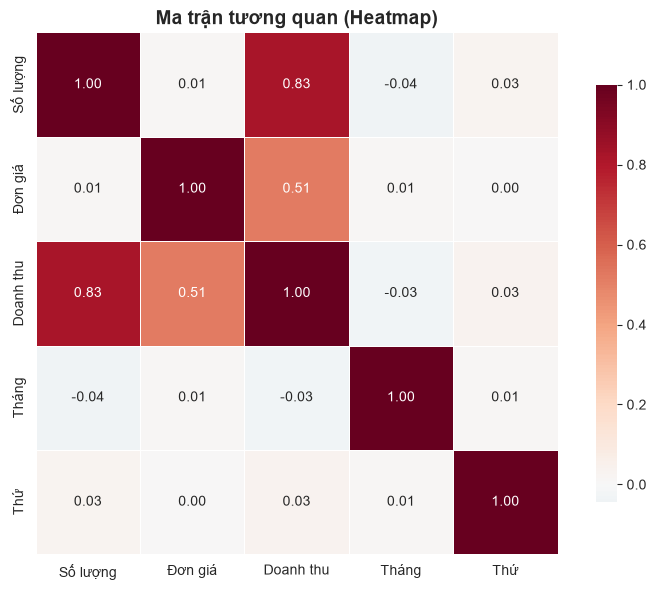

In [7]:
# 3d. Ma trận tương quan (heatmap - Slide 25)
corr_cols = ['So_luong', 'Gia_Don_Hang', 'Doanh thu', 'Thang', 'Thu']
corr_matrix = df[corr_cols].corr()

# Vietnamese labels for heatmap
corr_labels = {
    'So_luong': 'Số lượng',
    'Gia_Don_Hang': 'Đơn giá',
    'Doanh thu': 'Doanh thu',
    'Thang': 'Tháng',
    'Thu': 'Thứ',
}
corr_matrix_renamed = corr_matrix.rename(index=corr_labels, columns=corr_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix_renamed, annot=True, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, fmt='.2f',
            cbar_kws={'shrink': 0.8})
plt.title('Ma trận tương quan (Heatmap)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / '3d_ma_tran_tuong_quan.png', dpi=100, bbox_inches='tight')
plt.show()

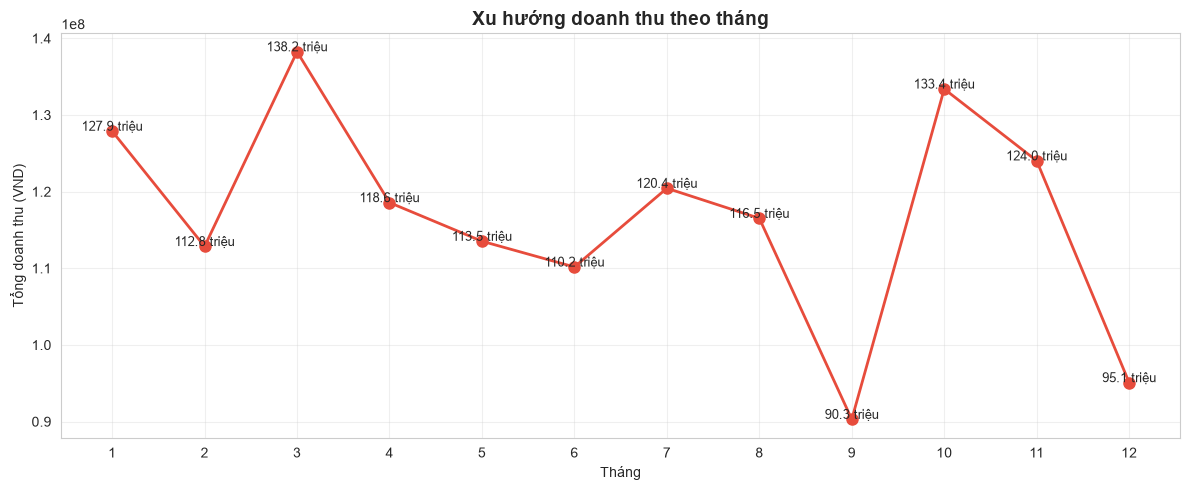

In [8]:
# 3e. Xu hướng doanh thu theo tháng
monthly_revenue = df.groupby('Thang')['Doanh thu'].sum()

plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o',
         linewidth=2, markersize=8, color='#e74c3c')
plt.title('Xu hướng doanh thu theo tháng', fontsize=14, fontweight='bold')
plt.xlabel('Tháng')
plt.ylabel('Tổng doanh thu (VND)')
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
for i, v in enumerate(monthly_revenue.values):
    plt.text(monthly_revenue.index[i], v + 50000, fmt_trieu(v), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(PLOT_DIR / '3e_xu_huong_doanh_thu.png', dpi=100, bbox_inches='tight')
plt.show()

In [9]:
# 3f. Doanh thu theo loại sản phẩm
product_revenue = df.groupby('Ten_SP')['Doanh thu'].agg(['sum', 'mean', 'count']).round(0)
product_revenue.columns = ['Tổng doanh thu', 'Doanh thu TB', 'Số giao dịch']
product_revenue['Tổng doanh thu'] = product_revenue['Tổng doanh thu'].astype(int)
product_revenue['Doanh thu TB'] = product_revenue['Doanh thu TB'].astype(int)

product_revenue.to_csv(METRIC_DIR / '3f_doanh_thu_theo_san_pham.csv', encoding='utf-8-sig')
product_revenue

,Tổng doanh thu,Doanh thu TB,Số giao dịch
Ten_SP,,,
Áo nam,595800000,1873585,318
Áo nữ,539220000,1514663,356
Áo trẻ em,266000000,810976,328


## 4. Handle Missing Values

Per Slide 13 methodology: identify missing data, then drop or impute using mean/median/mode.

In [10]:
# 4a. Check for missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Số lượng thiếu': missing, 'Tỷ lệ (%)': missing_pct.round(2)})
print('=== Phân tích giá trị thiếu ===')

if missing_df['Số lượng thiếu'].sum() > 0:
    display(missing_df[missing_df['Số lượng thiếu'] > 0])
else:
    print('Không tìm thấy giá trị thiếu trong dữ liệu.')

missing_df.to_csv(METRIC_DIR / '4a_gia_tri_thieu.csv', encoding='utf-8-sig')

=== Phân tích giá trị thiếu ===
Không tìm thấy giá trị thiếu trong dữ liệu.


**Kết quả: Không có giá trị thiếu trong bất kỳ cột nào.** Không cần xử lý thêm.

## 5. Detect & Treat Outliers

Per Slide 15 methodology: identify outliers via IQR, then decide to cap, remove, or retain.

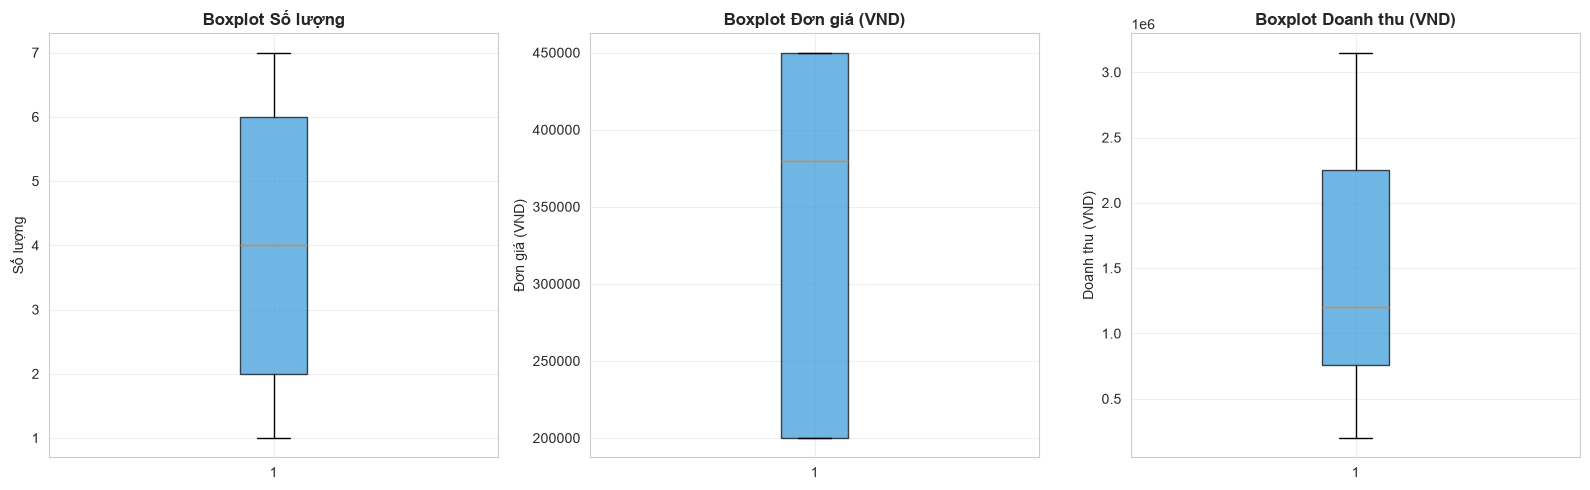

In [11]:
# 5a. Boxplot of numerical columns
num_cols_plot = ['So_luong', 'Gia_Don_Hang', 'Doanh thu']
box_labels = {'So_luong': 'Số lượng', 'Gia_Don_Hang': 'Đơn giá (VND)', 'Doanh thu': 'Doanh thu (VND)'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, num_cols_plot):
    bp = ax.boxplot(df[col], patch_artist=True)
    bp['boxes'][0].set_facecolor('#3498db')
    bp['boxes'][0].set_alpha(0.7)
    ax.set_title(f'Boxplot {box_labels[col]}', fontsize=12, fontweight='bold')
    ax.set_ylabel(box_labels[col])
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_DIR / '5a_boxplot_outlier.png', dpi=100, bbox_inches='tight')
plt.show()

In [12]:
# 5b. IQR-based outlier detection
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

outlier_results = {}
print('=== Phát hiện ngoại lai theo IQR ===')
for col in num_cols_plot:
    outliers, lb, ub = detect_outliers_iqr(df, col)
    outlier_results[col] = {'count': int(len(outliers)), 'lower_bound': float(lb), 'upper_bound': float(ub)}
    print(f'{box_labels[col]}: {len(outliers)} giá trị ngoại lai '
          f'(ngưỡng: [{lb:.0f}, {ub:.0f}])')

outlier_df = pd.DataFrame(outlier_results).T
outlier_df.to_csv(METRIC_DIR / '5b_phat_hien_ngoai_lai.csv', encoding='utf-8-sig')

=== Phát hiện ngoại lai theo IQR ===
Số lượng: 0 giá trị ngoại lai (ngưỡng: [-4, 12])
Đơn giá (VND): 0 giá trị ngoại lai (ngưỡng: [-175000, 825000])
Doanh thu (VND): 0 giá trị ngoại lai (ngưỡng: [-1475000, 4485000])


**Kết quả: 0 ngoại lai ở cả ba biến.** Đây là kỳ vọng — số lượng mỗi hóa đơn chỉ 1–7 sản phẩm và đơn giá chỉ có các mức rời rạc (200k / 380k / 450k VND). Không cần xử lý.

## 6. Feature Scaling

Per Slide 16 methodology: Min-Max ([0,1]) and Z-score (mean=0, std=1) normalization.

In [13]:
# 6a. Min-Max Scaling (range [0, 1])
scaler_mm = MinMaxScaler()
scaled_mm = scaler_mm.fit_transform(df[num_cols])
df_mm = pd.DataFrame(scaled_mm, columns=[f'{c}_MinMax' for c in num_cols])

print('=== Dữ liệu sau Min-Max Scaling [0, 1] ===')
print(df_mm.describe().round(4))

df_mm.describe().round(4).to_csv(METRIC_DIR / '6a_minmax_scaled.csv', encoding='utf-8-sig')

=== Dữ liệu sau Min-Max Scaling [0, 1] ===
       So_luong_MinMax  Gia_Don_Hang_MinMax  Doanh thu_MinMax
count        1002.0000            1002.0000         1002.0000
mean            0.5108               0.5732            0.4062
std             0.3349               0.4162            0.2861
min             0.0000               0.0000            0.0000
25%             0.1667               0.0000            0.1898
50%             0.5000               0.7200            0.3390
75%             0.8333               1.0000            0.6949
max             1.0000               1.0000            1.0000


In [14]:
# 6b. Z-score (Standardization, mean=0, std=1)
scaler_std = StandardScaler()
scaled_std = scaler_std.fit_transform(df[num_cols])
df_std = pd.DataFrame(scaled_std, columns=[f'{c}_Zscore' for c in num_cols])

print('=== Dữ liệu sau Z-score (mean=0, std=1) ===')
print(df_std.describe().round(4))

df_std.describe().round(4).to_csv(METRIC_DIR / '6b_zscore_scaled.csv', encoding='utf-8-sig')

=== Dữ liệu sau Z-score (mean=0, std=1) ===
       So_luong_Zscore  Gia_Don_Hang_Zscore  Doanh thu_Zscore
count        1002.0000            1002.0000         1002.0000
mean            0.0000              -0.0000           -0.0000
std             1.0005               1.0005            1.0005
min            -1.5262              -1.3780           -1.4204
25%            -1.0282              -1.3780           -0.7566
50%            -0.0323               0.3530           -0.2350
75%             0.9636               1.0261            1.0097
max             1.4616               1.0261            2.0766


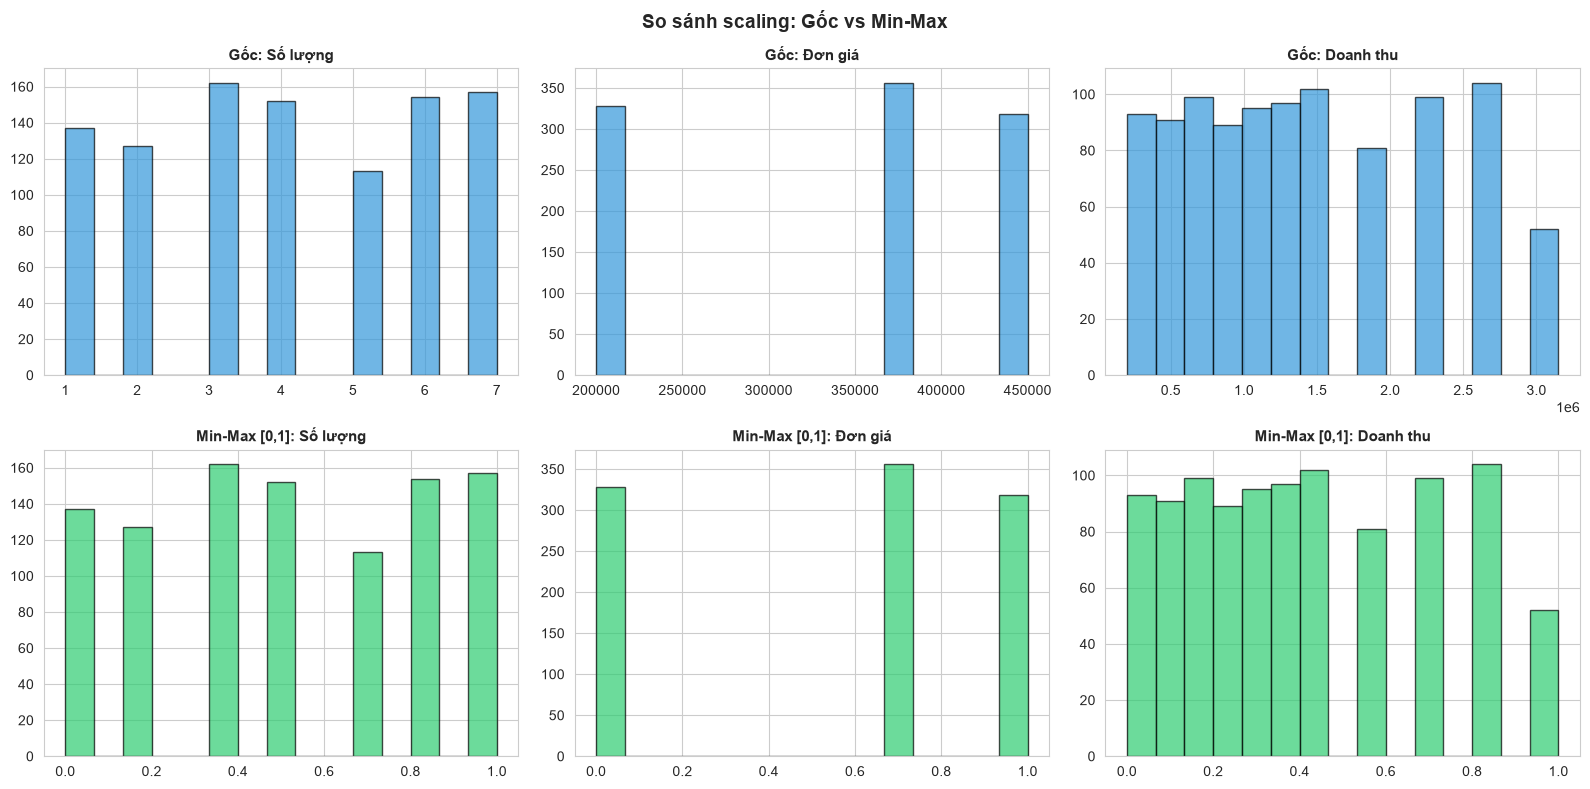

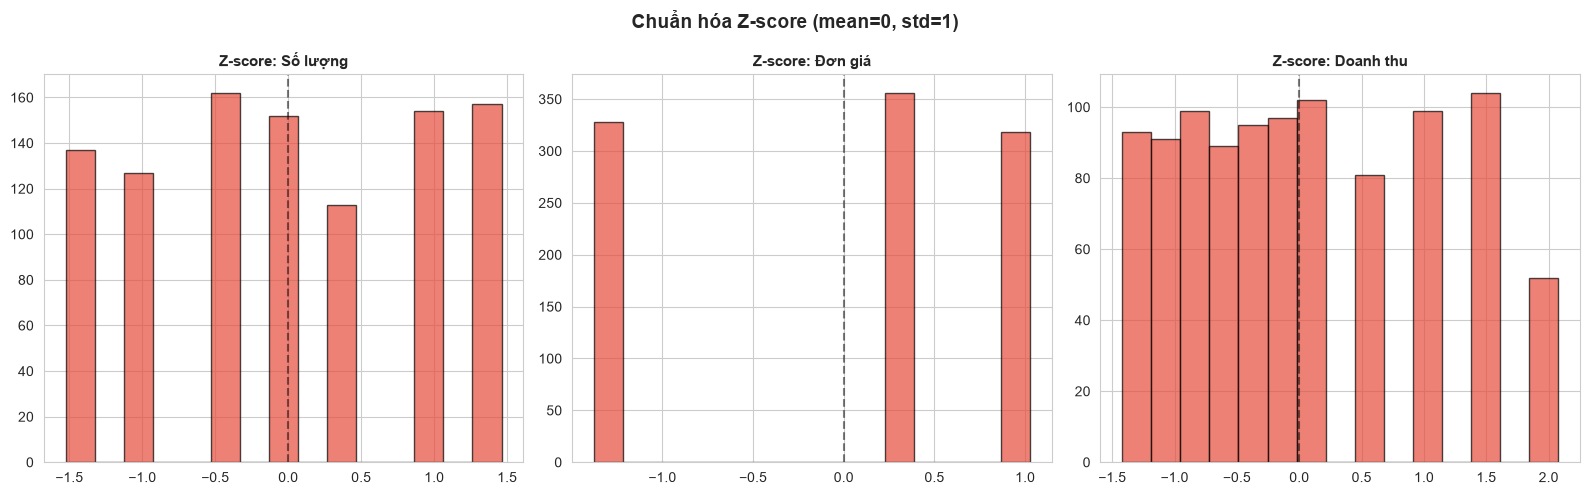

In [15]:
# 6c. Visual comparison of scaling methods
scale_labels = {
    'So_luong': 'Số lượng',
    'Gia_Don_Hang': 'Đơn giá',
    'Doanh thu': 'Doanh thu',
}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for i, col in enumerate(num_cols):
    axes[0, i].hist(df[col], bins=15, edgecolor='black', color='#3498db', alpha=0.7)
    axes[0, i].set_title(f'Gốc: {scale_labels[col]}', fontsize=11, fontweight='bold')
    axes[1, i].hist(df_mm[f'{col}_MinMax'], bins=15, edgecolor='black', color='#2ecc71', alpha=0.7)
    axes[1, i].set_title(f'Min-Max [0,1]: {scale_labels[col]}', fontsize=11, fontweight='bold')

plt.suptitle('So sánh scaling: Gốc vs Min-Max', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / '6c_so_sanh_minmax.png', dpi=100, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(num_cols):
    axes[i].hist(df_std[f'{col}_Zscore'], bins=15, edgecolor='black', color='#e74c3c', alpha=0.7)
    axes[i].set_title(f'Z-score: {scale_labels[col]}', fontsize=11, fontweight='bold')
    axes[i].axvline(0, color='black', linestyle='--', alpha=0.5)

plt.suptitle('Chuẩn hóa Z-score (mean=0, std=1)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / '6c_so_sanh_zscore.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. Data Visualization

Applying the guide's chart selection recommendations (Slides 19–26) to communicate findings with Vietnamese labels.

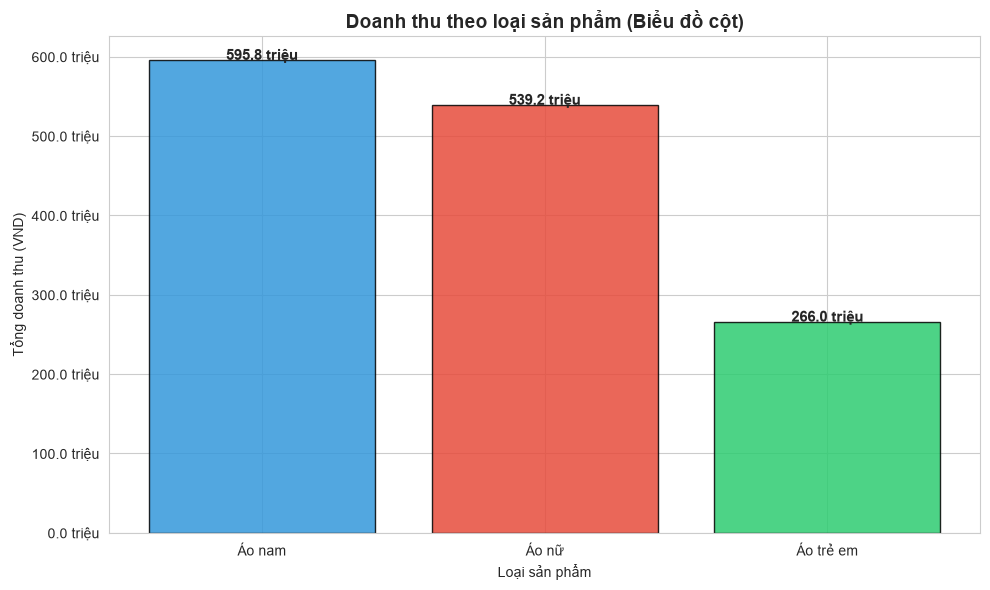

In [16]:
# 7a. Bar Chart — Doanh thu theo sản phẩm (Slide 20)
product_stats = df.groupby('Ten_SP').agg(
    Total_Revenue=('Doanh thu', 'sum'),
    Total_Quantity=('So_luong', 'sum'),
    Transactions=('STT', 'count')
).reset_index()

bar_colors = product_stats['Ten_SP'].map(PALETTE)
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(product_stats['Ten_SP'], product_stats['Total_Revenue'],
              color=bar_colors, edgecolor='black', alpha=0.85)
ax.set_title('Doanh thu theo loại sản phẩm (Biểu đồ cột)', fontsize=14, fontweight='bold')
ax.set_xlabel('Loại sản phẩm')
ax.set_ylabel('Tổng doanh thu (VND)')
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: fmt_trieu(x)))

for bar, val in zip(bars, product_stats['Total_Revenue']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20000,
            fmt_trieu(val), ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig(PLOT_DIR / '7a_doanh_thu_theo_san_pham.png', dpi=100, bbox_inches='tight')
plt.show()

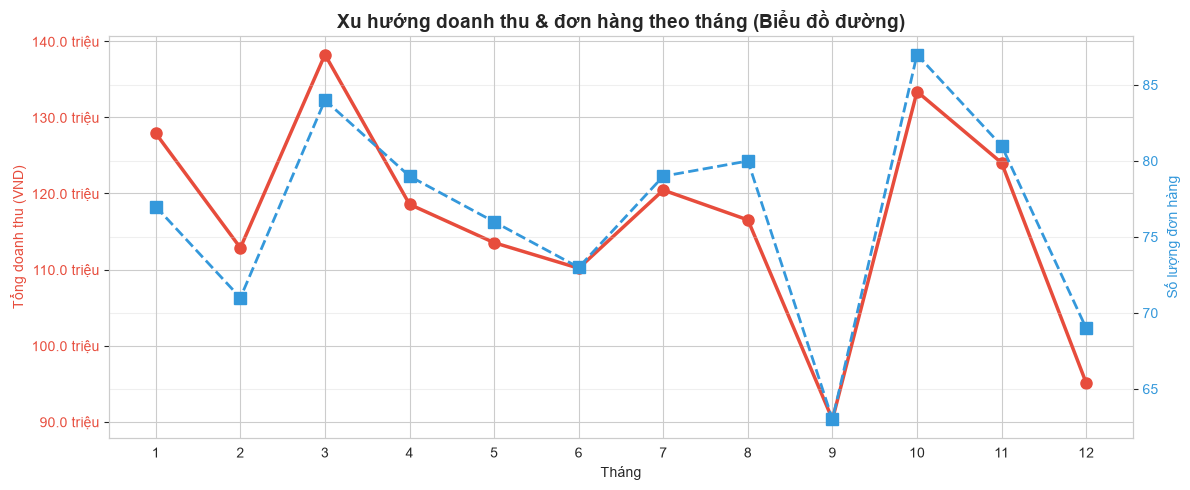

In [17]:
# 7b. Line Chart — Xu hướng doanh thu & đơn hàng theo tháng (Slide 21)
monthly_stats = df.groupby('Thang').agg(
    Revenue=('Doanh thu', 'sum'),
    Orders=('Ma_Don_hang', 'nunique')
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))

color1 = '#e74c3c'
ax1.plot(monthly_stats['Thang'], monthly_stats['Revenue'], marker='o',
         linewidth=2.5, markersize=8, color=color1, label='Doanh thu')
ax1.set_xlabel('Tháng')
ax1.set_ylabel('Tổng doanh thu (VND)', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: fmt_trieu(x)))

ax2 = ax1.twinx()
color2 = '#3498db'
ax2.plot(monthly_stats['Thang'], monthly_stats['Orders'], marker='s',
         linewidth=2, markersize=8, color=color2, linestyle='--', label='Đơn hàng')
ax2.set_ylabel('Số lượng đơn hàng', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Xu hướng doanh thu & đơn hàng theo tháng (Biểu đồ đường)', fontsize=14, fontweight='bold')
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / '7b_xu_huong_doanh_thu_don_hang.png', dpi=100, bbox_inches='tight')
plt.show()

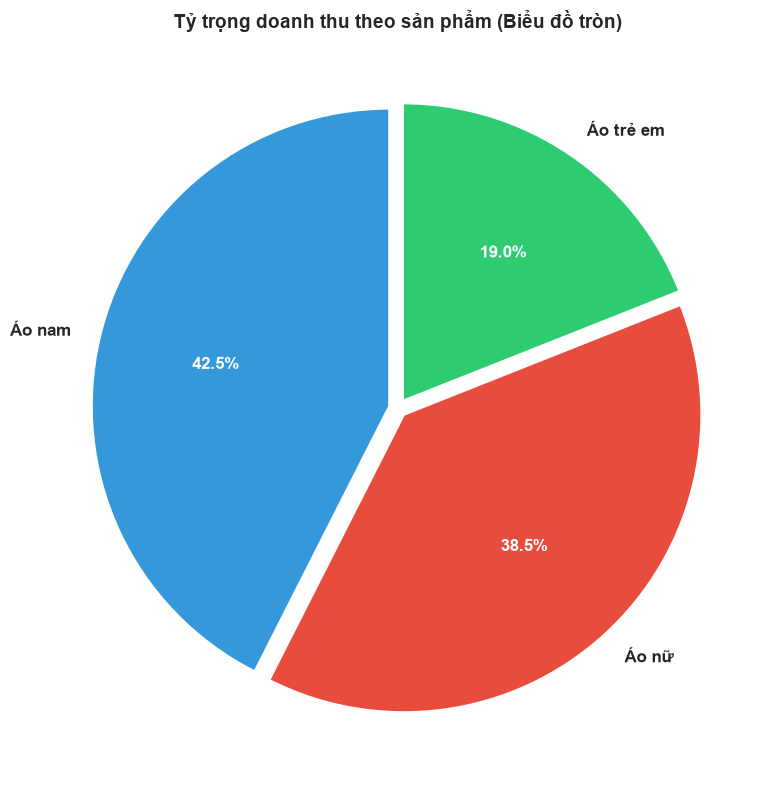

In [18]:
# 7c. Pie Chart — Tỷ trọng doanh thu theo sản phẩm (Slide 22)
product_share = df.groupby('Ten_SP')['Doanh thu'].sum()
pie_colors = [PALETTE[p] for p in product_share.index]

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    product_share.values, labels=product_share.index,
    autopct='%1.1f%%', startangle=90, colors=pie_colors,
    explode=(0.03, 0.03, 0.03),
    textprops={'fontsize': 12, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax.set_title('Tỷ trọng doanh thu theo sản phẩm (Biểu đồ tròn)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / '7c_ty_trong_doanh_thu.png', dpi=100, bbox_inches='tight')
plt.show()

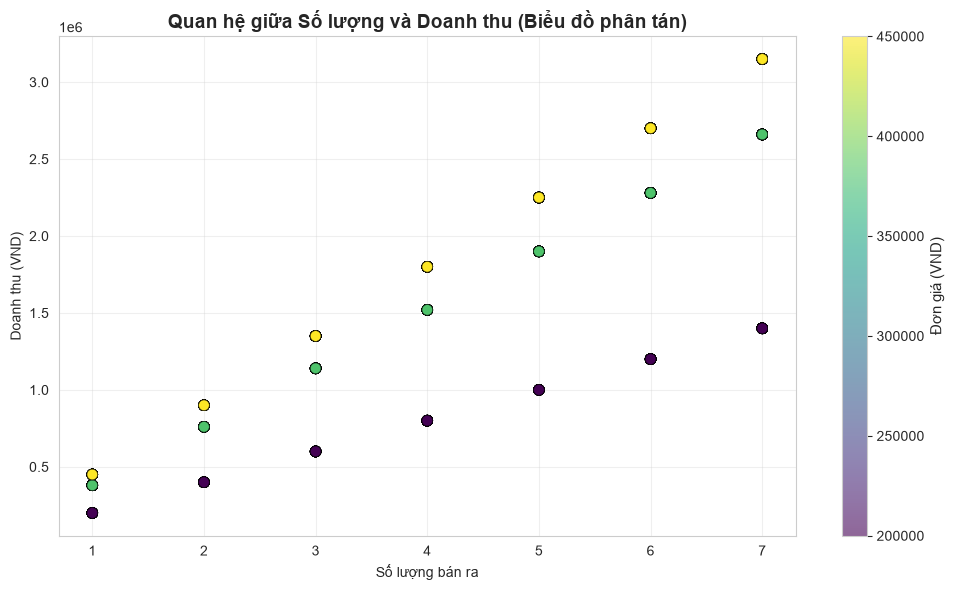

In [19]:
# 7d. Scatter Plot — Số lượng vs Doanh thu (Slide 23)
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['So_luong'], df['Doanh thu'],
                      c=df['Gia_Don_Hang'], cmap='viridis',
                      alpha=0.6, edgecolors='black', linewidths=0.5, s=60)
cbar = plt.colorbar(scatter)
cbar.set_label('Đơn giá (VND)', fontsize=11)
plt.title('Quan hệ giữa Số lượng và Doanh thu (Biểu đồ phân tán)', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng bán ra')
plt.ylabel('Doanh thu (VND)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / '7d_so_luong_vs_doanh_thu.png', dpi=100, bbox_inches='tight')
plt.show()

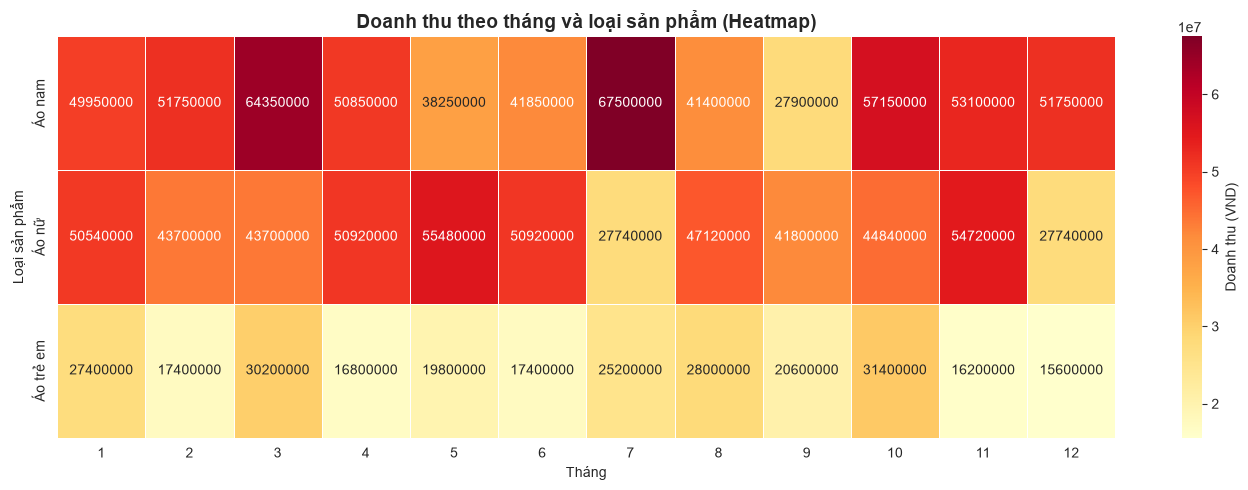

In [20]:
# 7e. Heatmap — Doanh thu theo tháng và sản phẩm (Slide 25)
monthly_product = df.pivot_table(
    values='Doanh thu', index='Ten_SP', columns='Thang',
    aggfunc='sum', fill_value=0
)

plt.figure(figsize=(14, 5))
sns.heatmap(monthly_product, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Doanh thu (VND)'})
plt.title('Doanh thu theo tháng và loại sản phẩm (Heatmap)', fontsize=14, fontweight='bold')
plt.xlabel('Tháng')
plt.ylabel('Loại sản phẩm')
plt.tight_layout()
plt.savefig(PLOT_DIR / '7e_heatmap_doanh_thu.png', dpi=100, bbox_inches='tight')
plt.show()

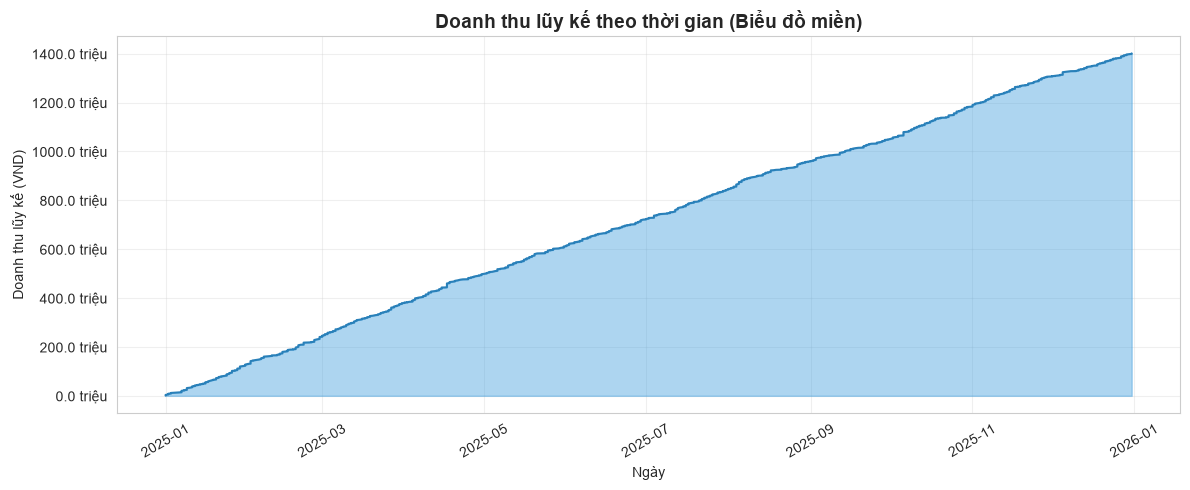

In [21]:
# 7f. Area Chart — Doanh thu lũy kế theo thời gian (Slide 24)
df_sorted = df.sort_values('Ngay_GD')
df_sorted['Doanh_thu_luy_ke'] = df_sorted['Doanh thu'].cumsum()

plt.figure(figsize=(12, 5))
plt.fill_between(df_sorted['Ngay_GD'], df_sorted['Doanh_thu_luy_ke'],
                 alpha=0.4, color='#3498db')
plt.plot(df_sorted['Ngay_GD'], df_sorted['Doanh_thu_luy_ke'],
         color='#2980b9', linewidth=1.5)
plt.title('Doanh thu lũy kế theo thời gian (Biểu đồ miền)', fontsize=14, fontweight='bold')
plt.xlabel('Ngày')
plt.ylabel('Doanh thu lũy kế (VND)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: fmt_trieu(x)))
plt.xticks(rotation=30)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / '7f_luy_ke_doanh_thu.png', dpi=100, bbox_inches='tight')
plt.show()

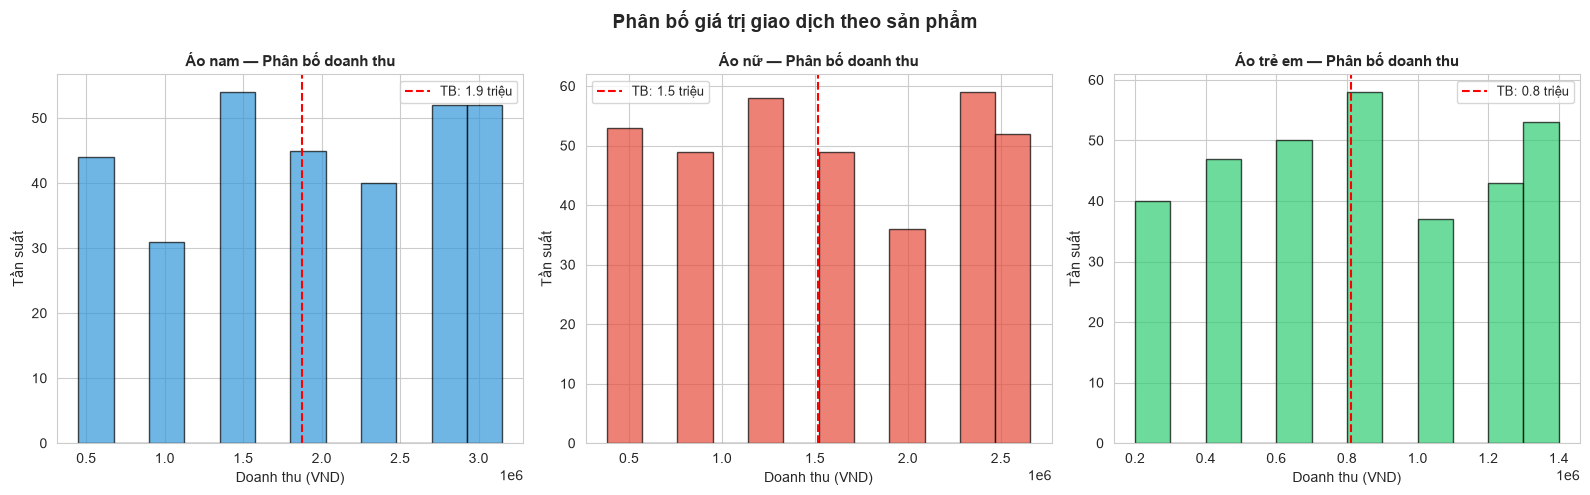

In [22]:
# 7g. Histogram — Phân bố giá trị giao dịch theo sản phẩm
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (product, group) in zip(axes, df.groupby('Ten_SP')):
    ax.hist(group['Doanh thu'], bins=12, edgecolor='black', alpha=0.7, color=PALETTE[product])
    ax.set_title(f'{product} — Phân bố doanh thu', fontsize=11, fontweight='bold')
    ax.set_xlabel('Doanh thu (VND)')
    ax.set_ylabel('Tần suất')
    ax.axvline(group['Doanh thu'].mean(), color='red', linestyle='--',
               label=f'TB: {fmt_trieu(group["Doanh thu"].mean())}')
    ax.legend(fontsize=9)

plt.suptitle('Phân bố giá trị giao dịch theo sản phẩm', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / '7g_phan_bo_giao_dich.png', dpi=100, bbox_inches='tight')
plt.show()

In [23]:
# Summary — Lưu số liệu tổng hợp
summary = {
    'Số bản ghi': [len(df)],
    'Số cột': [len(df.columns)],
    'Tổng doanh thu (VND)': [df['Doanh thu'].sum()],
    'Doanh thu trung bình (VND)': [df['Doanh thu'].mean()],
    'Số khách hàng': [df['Ma_KH'].nunique()],
    'Số đơn hàng': [df['Ma_Don_hang'].nunique()],
    'Giá trị thiếu': [0],
    'Giá trị ngoại lai (IQR)': [0],
}
pd.DataFrame(summary).to_csv(METRIC_DIR / '0_tong_hop.csv', index=False, encoding='utf-8-sig')

print('=== Tổng kết quá trình xử lý ===')
print(f'Số bản ghi: {len(df):,}')
print(f'Số cột: {len(df.columns)}')
print(f'Tổng doanh thu: {fmt_trieu(df["Doanh thu"].sum())} VND')
print(f'Giá trị thiếu: 0 (không phát hiện)')
print(f'Giá trị ngoại lai (IQR): 0 (không phát hiện)')
print(f'Đã scaling: Min-Max + Z-score')
print(f'Biểu đồ đã lưu: {PLOT_DIR}')
print(f'Số liệu đã lưu: {METRIC_DIR}')
print()
print('Hoàn tất quy trình theo Chương 2.')

=== Tổng kết quá trình xử lý ===
Số bản ghi: 1,002
Số cột: 13
Tổng doanh thu: 1401.0 triệu VND
Giá trị thiếu: 0 (không phát hiện)
Giá trị ngoại lai (IQR): 0 (không phát hiện)
Đã scaling: Min-Max + Z-score
Biểu đồ đã lưu: result\plots
Số liệu đã lưu: result\metrics

Hoàn tất quy trình theo Chương 2.
